In [1]:
## install finrl library if not installed

import pkg_resources
import pip
installedPackages = {pkg.key for pkg in pkg_resources.working_set} # list of installed packages

if 'finrl' not in installedPackages:
    !pip install git+https://github.com/AI4Finance-LLC/FinRL-Library.git #clone the FinRL library to install required packages
required = {'yfinance', 'pandas','numpy', 'matplotlib', 'stockstats','stable-baselines',
            'gym','pyfolio', 'ta', 'PyPortfolioOpt','pyfolio-reloaded','empyrical'
            }
missing = required - installedPackages
if missing:
    !pip install yfinance
    !pip install pandas
    !pip install numpy
    !pip install matplotlib
    !pip install stockstats
    !pip install gym
    !pip install stable-baselines3[extra]
    !pip install git+https://github.com/quantopian/pyfolio
    !pip install ta
    !pip install PyPortfolioOpt
    !pip install pyfolio-reloaded
    !pip install empyrical

<ipython-input-1-d3aba6510b78>:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/usr/local/lib/python3.10/dist-packages/_distutils_hack/__init__.py:31: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


  Cloning https://github.com/AI4Finance-LLC/FinRL-Library.git to /tmp/pip-req-build-p42alayp
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-LLC/FinRL-Library.git /tmp/pip-req-build-p42alayp
  Resolved https://github.com/AI4Finance-LLC/FinRL-Library.git to commit bc12fe7b57c483e8fac666f4cf05cbf62077958a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-yzsmzq11/elegantrl_48b3f617798f42deac4dd98a31a571a4
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /tmp/pip-install-yzsmzq11/elegantrl_48b3f617798f42deac4dd98a31a571a4
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 59d9a33e2b3ba2d77c052c2810bb61059736d88c
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("drive/My Drive/Asset_Allocation")

Mounted at /content/drive


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

import yfinance as yf
from pandas_datareader import data as pdr
import seaborn as sns
%matplotlib inline


from IPython.display import display, HTML
from datetime import datetime
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import objective_functions
from pypfopt import risk_models
from pypfopt import expected_returns
from empyrical import sharpe_ratio, annual_return

import warnings
warnings.filterwarnings('ignore')

In [58]:
def capital(weights,test_df_pivot,unique_trade_date,portfolio):
  for t,t_1 in zip(unique_trade_date[:-1],unique_trade_date[1::]):
    weight = weights.loc[t]
    #current capital
    cap = portfolio.loc[t,'account_value']
    #current cash invested for each stock
    current_cash = [element * cap for element in list(weight.values)]
    # current held shares
    current_shares = list(np.array(current_cash)
                                      / np.array(test_df_pivot.loc[t]))
    # next time period price
    next_price = np.array(test_df_pivot.loc[t_1])
    ##next_price * current share to calculate next total account value

    portfolio.loc[t_1, 'account_value'] = np.dot(current_shares, next_price)

  return portfolio

def max_sharpe_weights(df_ret,df_cov,unique_trade_date):
  weights = pd.DataFrame()
  for t,t_1 in zip(unique_trade_date[:-1],unique_trade_date[1::]):

    mu = df_ret[df_ret.Date == str(t)].iloc[::,1::]*12
    sigma = df_cov[df_cov.Date == str(t)].iloc[::,1::].set_index('Ticker')*12


    try:
      ef = EfficientFrontier(mu.iloc[0],sigma)
      ef.add_objective(objective_functions.L2_reg, gamma=0.1)
      raw_weights = ef.max_sharpe( )
    except:
      print('min_volatility')
      ef = EfficientFrontier(mu.iloc[0],sigma)
      raw_weights = ef.min_volatility()
    cleaned_weights = ef.clean_weights()
    max_sharpe_portfolio = pd.DataFrame(cleaned_weights, index=[0])
    max_sharpe_portfolio['Date'] = t
    weights = pd.concat([weights,max_sharpe_portfolio])

  return weights

In [4]:
train_df = pd.read_pickle('datasets/train_data_m1_result.pkl')
test_df = pd.read_pickle('datasets/test_data_m1_result.pkl')

In [5]:
train_df.isna().sum().sum(),test_df.isna().sum().sum()

(0, 0)

<Axes: xlabel='Date'>

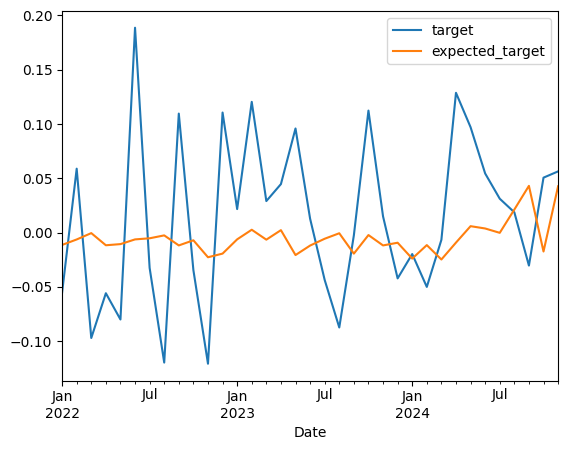

In [6]:
test_df[test_df.Ticker == 'AAPL'].plot.line(y=["target","expected_target"], x='Date')

In [9]:
print(len(train_df.Ticker.value_counts()))
test_df.head()

30


,Date,Ticker,close,high,low,open,volume,monthly_return,target,monthly_return_6_sma,...,supertrend_ub,supertrend_lb,vwma_3,gdp,unemployment rate,consumer price index,federal funds rate,interest rate,federal debt,expected_target
0,2022-01-01,AAPL,171.963135,179.991627,152.206755,174.963982,2108446000,-0.015712,-0.055270,0.032750,...,211.120358,123.331121,165.629770,25215.491000,4.000000,282.390000,0.080000,0.070000,30400960.0,-0.011409
1,2022-02-01,AAPL,162.458786,173.802958,149.550243,171.205507,1627516300,-0.055270,0.058821,0.016717,...,210.250214,123.331121,167.102232,25412.257667,3.900000,284.514667,0.163333,0.156667,30456834.0,-0.006378
2,2022-03-01,AAPL,172.014725,176.940408,147.869029,162.252016,2180800100,0.058821,-0.097131,0.037627,...,210.250214,123.331121,165.469911,25609.024333,3.800000,286.639333,0.246667,0.243333,30512708.0,-0.000526
3,2022-04-01,AAPL,155.306808,175.837071,153.070559,171.443354,1687795600,-0.097131,-0.055883,0.011663,...,210.250214,123.331121,163.230305,25805.791000,3.700000,288.764000,0.330000,0.330000,30568582.0,-0.011719
4,2022-05-01,AAPL,146.627747,164.005558,130.638982,154.380783,2401040300,-0.055883,-0.080080,-0.014896,...,203.264588,123.331121,157.385092,25961.197667,3.633333,290.835000,0.780000,0.746667,30688692.0,-0.010657



Maximum Sharpe Portfolio
---
We use PyPortfolioOpt library to get the weights for the Maximum Sharpe Portfolio

In [53]:
unique_trade_date = test_df.Date.unique()
test_df_pivot = test_df.pivot(index='Date', columns='Ticker', values='close')
data = pd.concat([train_df,test_df])
data_pivot = data.pivot(index='Date', columns='Ticker', values='close')
data_returns = data_pivot.pct_change() # get the assets monthly returns
df_ret = (data_returns.rolling(12).mean()*12).reset_index()
df_cov = (data_returns.rolling(12).cov()*12).reset_index()
data_returns.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-01,0.065396,-0.031977,-0.055897,0.018492,0.042244,0.099526,0.069237,0.082777,0.002496,0.057191,...,0.017389,0.060392,0.052632,0.035489,0.000473,0.037892,0.026061,0.039619,-0.002443,0.011978
2010-03-01,0.148470,0.057057,0.146706,0.080387,0.157468,0.101665,0.095659,0.069873,0.058863,0.117478,...,0.026402,0.087279,0.074074,-0.000158,0.073873,0.025670,-0.035145,0.069030,0.072243,0.028297
2010-04-01,0.111022,-0.042279,0.009796,0.122662,-0.002479,0.083373,0.149765,0.034576,0.073982,0.055285,...,0.042676,0.036928,-0.097127,-0.017544,0.153517,-0.053535,-0.072238,-0.008788,-0.068343,-0.029814
2010-05-01,-0.016125,-0.096493,-0.084902,-0.135517,-0.113903,-0.102086,0.010864,-0.139993,-0.092952,-0.092834,...,-0.155206,-0.046503,-0.163590,-0.009650,-0.018445,-0.025029,-0.040029,-0.196942,-0.033029,-0.057419


In [54]:
data.Date.max(),data.Date.min(), len(unique_trade_date)

(Timestamp('2024-11-01 00:00:00'), Timestamp('2010-01-01 00:00:00'), 35)

In [59]:
min_var_weights  =  max_sharpe_weights(df_ret,df_cov,unique_trade_date)
min_var_weights.Date = pd.to_datetime(min_var_weights.Date)
min_var_weights.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT,Date
0,0.10729,0.0,0.0,0.19646,0.0,0.0,0.01708,0.0,0.20714,0.0,...,0.0,0.14432,0.16933,0.00000,0.01136,0.0,0.0,0.0,0.0,2022-01-01
0,0.04855,0.0,0.0,0.28082,0.0,0.0,0.00000,0.0,0.23954,0.0,...,0.0,0.17055,0.19137,0.00000,0.00054,0.0,0.0,0.0,0.0,2022-02-01
0,0.06550,0.0,0.0,0.26435,0.0,0.0,0.00000,0.0,0.25486,0.0,...,0.0,0.16928,0.16429,0.00000,0.01480,0.0,0.0,0.0,0.0,2022-03-01
0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.00000,0.0,0.41046,0.0,...,0.0,0.06614,0.50840,0.00000,0.00000,0.0,0.0,0.0,0.0,2022-04-01
0,0.07526,0.0,0.0,0.00000,0.0,0.0,0.00000,0.0,0.52392,0.0,...,0.0,0.01824,0.33039,0.05218,0.00000,0.0,0.0,0.0,0.0,2022-05-01


In [56]:
#min_var_capital
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
min_var_capital =  capital(min_var_weights.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

Sharpe Ratio: 0.8104270337178788
Annual Return: 0.15419158565547386


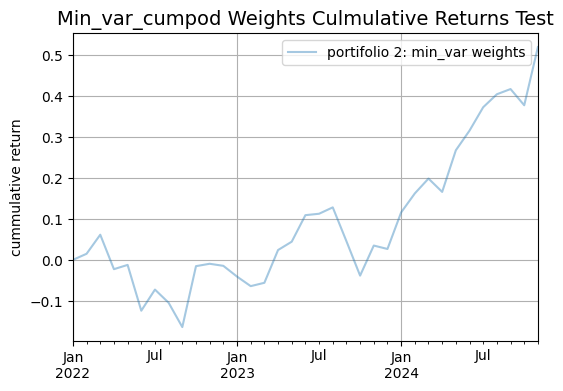

In [69]:
# Plotting the cummulative return
min_var_returns = min_var_capital.account_value.pct_change()
min_var_cumpod =(min_var_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
min_var_cumpod.name = "portifolio 2: min_var weights"

fig, ax = plt.subplots(figsize=(6,4))
min_var_cumpod.plot(ax=ax, alpha=0.4);

plt.legend(loc="best");
plt.grid(True)
ax.set_ylabel("cummulative return");
ax.set_title('Min_var_cumpod Weights Culmulative Returns Test', fontsize=14)

print('Sharpe Ratio:', sharpe_ratio(min_var_returns.values, period='monthly'))
print('Annual Return:', annual_return(min_var_returns.values, period='monthly'))

## Baseline Uniform Portfolio

In [39]:
ticker_list = test_df_pivot.columns # Get List of all ticker symbols
n_assets = len(ticker_list) # Number of assets
print(n_assets)
uniform_weights = np.ones((n_assets))/n_assets

uniform_weights_port = pd.DataFrame([uniform_weights], columns = ticker_list)

print("\nuniform weights portfolio:\n")
uniform_weights = min_var_weights.copy()
uniform_weights.iloc[::,:30] = uniform_weights_port
uniform_weights.Date = pd.to_datetime(uniform_weights.Date)
uniform_weights.head()

30

uniform weights portfolio:



,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT,Date
0,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,2022-01-01
0,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,2022-02-01
0,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,2022-03-01
0,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,2022-04-01
0,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,2022-05-01


In [40]:
#uniform_weights_capital
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
uniform_capital =  capital(uniform_weights.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

Sharpe Ratio: 0.8832572719122871
Annual Return: 0.14318654888646742


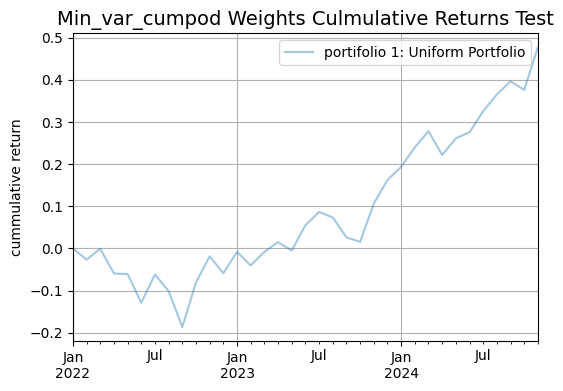

In [42]:
#uniform
uniform_returns = uniform_capital.account_value.pct_change()
uniform_cumpod =(uniform_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
uniform_cumpod.name = "portifolio 1: Uniform Portfolio"

fig, ax = plt.subplots(figsize=(6,4))
uniform_cumpod.plot(ax=ax, alpha=0.4);

plt.legend(loc="best");
plt.grid(True)
ax.set_ylabel("cummulative return");
ax.set_title('Min_var_cumpod Weights Culmulative Returns Test', fontsize=14)

print('Sharpe Ratio:', sharpe_ratio(uniform_returns.values, period='monthly'))
print('Annual Return:', annual_return(uniform_returns.values, period='monthly'))

## min_var Portfolio with Predicted Returns



In [60]:
test_expected_return_df_pivot = test_df.pivot(index='Date', columns='Ticker', values='expected_target')
df_ret = (test_expected_return_df_pivot*12).reset_index()
df_cov = (data_returns.rolling(12).cov()*12).reset_index()
df_ret.head()

Ticker,Date,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
0,2022-01-01,-0.136910,0.362154,0.143392,0.068416,-0.160810,0.087054,0.052481,-0.724373,-0.205511,...,-0.113221,0.087136,-0.249931,0.185784,0.127993,0.041377,0.086272,0.010310,0.069652,-0.184327
1,2022-02-01,-0.076537,0.279371,0.159088,0.189157,0.129718,0.057486,-0.091137,-0.750192,-0.107984,...,0.016703,0.164482,0.144170,0.285511,0.091186,0.193551,0.347127,0.524025,0.053873,-0.405673
2,2022-03-01,-0.006307,0.240961,0.265083,0.111575,-0.013683,0.044680,0.232890,-0.345606,-0.313697,...,0.045557,0.150941,0.437290,0.173281,0.088625,0.109651,0.342356,-0.005779,0.317871,-0.151932
3,2022-04-01,-0.140627,-0.012984,0.151965,-0.052852,0.104384,0.159979,-0.057216,-0.094134,-0.041294,...,-0.114160,0.379246,0.215467,0.303784,0.012056,0.109236,0.174899,0.605157,0.113721,0.445511
4,2022-05-01,-0.127883,0.457456,0.089988,0.098247,-0.113025,0.251636,-0.079256,-0.403882,-0.011244,...,0.121339,0.125201,-0.021052,0.206706,0.222545,0.177659,0.349203,0.099178,0.129325,0.162977


In [61]:
min_var_weights_with_predictions  =  max_sharpe_weights(df_ret,df_cov,unique_trade_date)
min_var_weights_with_predictions.Date = pd.to_datetime(min_var_weights_with_predictions.Date)
min_var_weights_with_predictions.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT,Date
0,0.0,0.07224,0.00618,0.00000,0.00000,0.0,0.09140,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,0.00000,2022-01-01
0,0.0,0.00000,0.00000,0.00000,0.13956,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.14735,0.07055,0.0,0.10006,0.0,0.41534,0.00000,0.00000,2022-02-01
0,0.0,0.00000,0.06246,0.00000,0.08266,0.0,0.00239,0.0,0.0,0.0,...,0.0,0.08320,0.00000,0.0,0.00000,0.0,0.00000,0.47302,0.00000,2022-03-01
0,0.0,0.00000,0.00000,0.00000,0.03775,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.04697,0.04494,0.0,0.00000,0.0,0.28842,0.04830,0.31233,2022-04-01
0,0.0,0.28227,0.02938,0.01023,0.00000,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.00000,0.00013,0.0,0.00000,0.0,0.00000,0.10411,0.14160,2022-05-01


In [62]:
#min_var_capital
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
method1_capital =  capital(min_var_weights_with_predictions.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

Sharpe Ratio: 0.2469125482532098
Annual Return: 0.02798598638720473


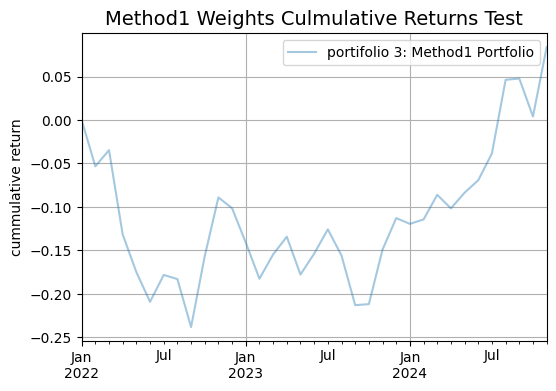

In [65]:
#method1
method1_returns = method1_capital.account_value.pct_change()
method1_cumpod =(method1_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
method1_cumpod.name = "portifolio 3: Method1 Portfolio"

fig, ax = plt.subplots(figsize=(6,4))
method1_cumpod.plot(ax=ax, alpha=0.4);

plt.legend(loc="best");
plt.grid(True)
ax.set_ylabel("cummulative return");
ax.set_title('Method1 Weights Culmulative Returns Test', fontsize=14)

print('Sharpe Ratio:', sharpe_ratio(method1_returns.values, period='monthly'))
print('Annual Return:', annual_return(method1_returns.values, period='monthly'))

##Compare All the Results

In [66]:
tickers = test_df_pivot.columns.tolist()

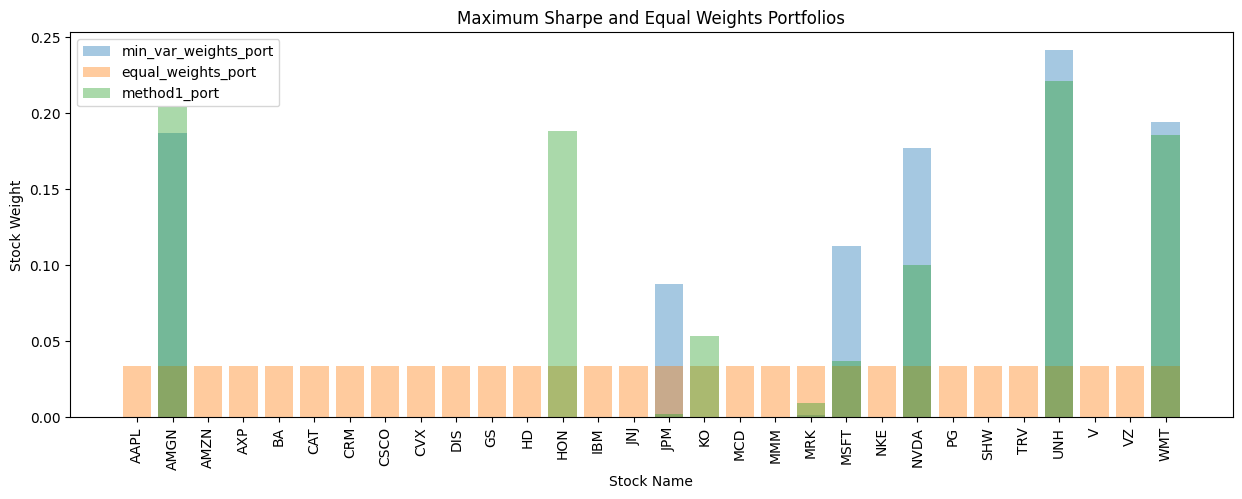

In [71]:
date = '2024-01-01'
plt.subplots(figsize=(15,5))
plt.title('Maximum Sharpe and Equal Weights Portfolios')
plt.bar(tickers, min_var_weights.loc[min_var_weights.Date == date,tickers].T[0], alpha=0.4, label='min_var_weights_port')
plt.bar(uniform_weights_port.T.index, uniform_weights_port.T[0], alpha=0.4, label='equal_weights_port')
plt.bar(tickers, min_var_weights_with_predictions.loc[min_var_weights_with_predictions.Date == date,tickers].T[0], alpha=0.4, label='method1_port')
plt.xlabel('Stock Name')
plt.ylabel('Stock Weight')
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [68]:
min_var_weights.to_pickle('datasets/max_sharpe_weights.pkl')
uniform_weights.to_pickle('datasets/uniform_weights_port.pkl')
min_var_weights_with_predictions.to_pickle('datasets/min_var_weights_with_predictions.pkl')